In [ ]:
f(x, y) = sin(x + y) + cos(x)^2
f(v) = sin(v[1] + v[2]) + cos(v[1])^2

f (generic function with 2 methods)

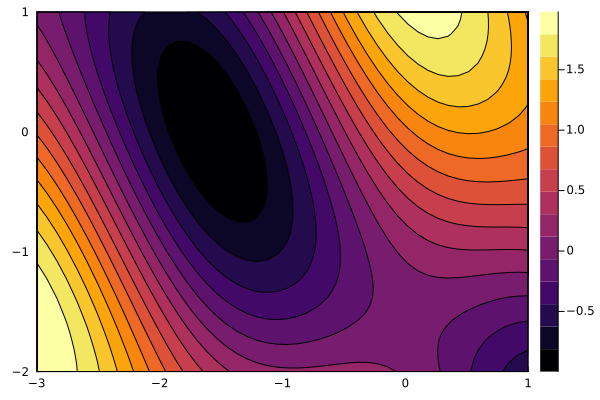

In [ ]:
# https://docs.juliaplots.org/dev/series_types/contour/

using Plots

x = range(-3, 1, length=50)
y = range(-2, 1, length=50)

# The ' in x' is the adjoint operator and makes x a row vector.
# Basicamente sin la apóstrofe, x es un tipo range.

# El macro @. evalua lo que este a la derecha element-wise.
z = @. f(x', y)

contourf(x, y, z)

In [ ]:
df(f, x, h=0.06) = (f(x + h) - f(x)) / h

df (generic function with 2 methods)

In [ ]:
function grad(f, x)
    grads = []

    # Para cada variable x_i del vector x definimos una funcion que devuelve f
    # solo en funcion de la variable x_i, las demas como constante.
    for i in eachindex(x)
        function fi(x_i)
            x_temp = copy(x)
            x_temp[i] = x_i
            return f(x_temp)
        end

        push!(grads, df(fi, x[i]))
    end
    return grads
end

grad (generic function with 1 method)

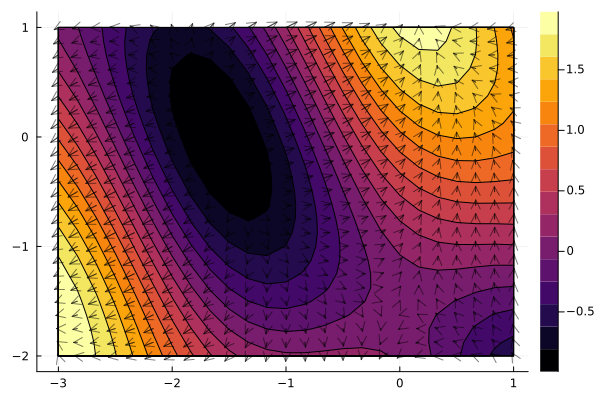

In [ ]:
xs = range(-3, 1, length=25)
ys = range(-2, 1, length=25)
z = @. f(xs', ys)

plt = contourf(xs, ys, z)
α = 0.05
for x1 in xs, x2 in ys
    x = [x1; x2]
    g_val = grad(f, x)
    x_grad = [x x .+ α .* g_val]

    plot!(plt, x_grad[1, :], x_grad[2, :];
        line = (:arrow, 0.5, :black),
        label = "",
    )
end
display(plt)

In [ ]:
function grad_descent(f, grad, x_0, alpha)
    x = []
    push!(x, x_0 - alpha * grad(f, x_0))
    for k in range(2, 100)
        x_k = x[k-1] - alpha * grad(f, x[k-1])
        push!(x, x_k)
    end
    return x
end

grad_descent (generic function with 1 method)

In [ ]:
function create_anim(
    f,
    path,
    xlims,
    ylims,
    file_name = joinpath(pwd(), randstring(12) * ".gif");
    xbounds = xlims,
    ybounds = ylims,
    fps = 15,
)
    xs = range(xlims...; length = 100)
    ys = range(ylims...; length = 100)
    plt = contourf(xs, ys, f; color = :jet)

    # add constraints if provided
    if !(xbounds == xlims && ybounds == ylims)
        x_rect = [xbounds[1]; xbounds[2]; xbounds[2]; xbounds[1]; xbounds[1]]
        y_rect = [ybounds[1]; ybounds[1]; ybounds[2]; ybounds[2]; ybounds[1]]

        plot!(x_rect, y_rect; line = (2, :dash, :red), label="")
    end

    # add an empty plot
    plot!(Float64[], Float64[]; line = (4, :arrow, :black), label = "")

    # extract the last plot series
    plt_path = plt.series_list[end]

    # create the animation and save it
    anim = Animation()
    for x in eachcol(path)
        push!(plt_path, x[1], x[2]) # add a new point
        frame(anim)
    end
    gif(anim, file_name; fps = fps, show_msg = false)
    return nothing
end

create_anim (generic function with 2 methods)

In [ ]:
x_0 = [0.0, -1.0]
alphas = [0.01, 0.1, 1.0]

xlims = [-3.0, 1.0]
ylims = [-2.0, 1.0]

for alpha in alphas
    path_vector = grad_descent(f, grad, x_0, alpha)
    path_matrix = hcat(path_vector...)
    filename = "gradient_descent_alpha_$(alpha).gif"
    println("Generando animacion para alpha = $(alpha) en $(filename)...")
    create_anim(f, path_matrix, xlims, ylims, filename)
    println("Animacion generada correctamente.")
end

Generating animation for alpha = 0.01 as gradient_descent_alpha_0.01.gif...
Animation generated successfully.
Generating animation for alpha = 0.1 as gradient_descent_alpha_0.1.gif...
Animation generated successfully.
Generating animation for alpha = 1.0 as gradient_descent_alpha_1.0.gif...
Animation generated successfully.


In [ ]:
function newton(f, x_0; eps=1e-3, max_iter=100)
    x = x_0 - (f(x_0) / df(f, x_0))
    for i in range(iter_max)
        x = x - df(f, x)
    end
end